# Model Evaluation

Deep evaluation of the tuned gradient-boosting model (models/hgb_tuned.joblib).
The headline metrics already tell us the model is good on average; But here we analyze exactly how right or wrong it is

Inputs: hgb_tuned.joblib, X_test.parquet, y_test.parquet,metrics.csv

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (mean_absolute_error, mean_absolute_percentage_error,
                             mean_squared_error, r2_score)
from sklearn.inspection import permutation_importance

from src.config import CFG, resolve

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

FIGS = resolve(CFG["paths"]["figures"]); FIGS.mkdir(parents=True, exist_ok=True)


def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIGS / f"{name}.png", dpi=130, bbox_inches="tight")
    print("saved", FIGS / f"{name}.png")

In [2]:
proc = resolve(CFG["paths"]["processed"]).parent
X_test = pd.read_parquet(proc / "X_test.parquet")
y_test = pd.read_parquet(proc / "y_test.parquet").iloc[:, 0]

model = joblib.load(resolve(CFG["paths"]["models"]) / "hgb_tuned.joblib")
y_pred = model.predict(X_test)

ev = X_test.copy()
ev["y_true"] = y_test.to_numpy()
ev["y_pred"] = y_pred
ev["error"] = ev["y_pred"] - ev["y_true"]
ev["pct_err"] = ev["error"] / ev["y_true"] * 100
ev["abs_pct_err"] = ev["pct_err"].abs()
print(f"evaluating tuned HGB on {len(ev):,} test rows")
ev[["y_true", "y_pred", "pct_err"]].describe()

evaluating tuned HGB on 262,235 test rows


,y_true,y_pred,pct_err
count,"262,235.00","262,235.00","262,235.00"
mean,"2,926,234.85","2,555,930.54",-3.90
std,"5,295,337.00","4,387,840.17",94.96
min,"50,000.00","62,774.35",-99.40
25%,"975,000.00","901,709.60",-19.62
50%,"1,569,666.00","1,430,908.14",-8.63
75%,"2,850,000.00","2,578,560.51",2.82
max,"100,000,000.00","136,122,254.76","23,362.08"


## 1. Model comparison

The tuned model against the three baselines from train.py

       model         rmse          mae   r2  mape
0      ridge 4,494,312.99 1,256,903.76 0.28  0.33
1        hgb 2,594,012.00   717,939.35 0.76  0.22
2        mlp 3,313,907.67   843,445.91 0.61  0.26
3  hgb_tuned 2,468,400.72   685,528.33 0.78  0.21
saved C:\Users\Maga\Study\CSCi323\Project\reports\figures\model_comparison.png


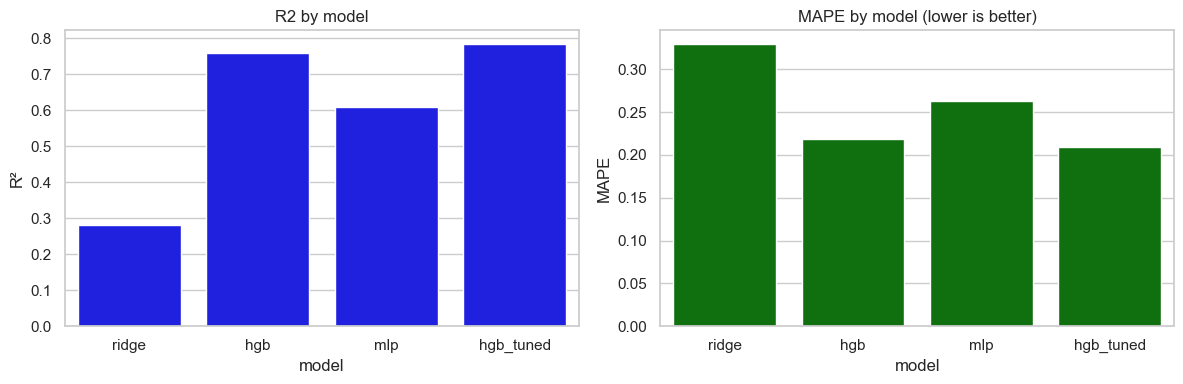

In [5]:
metrics = pd.read_csv(resolve(CFG["paths"]["figures"]).parent / "metrics.csv")
tuned = {"model": "hgb_tuned",
         "rmse": mean_squared_error(y_test, y_pred) ** 0.5,
         "mae": mean_absolute_error(y_test, y_pred),
         "r2": r2_score(y_test, y_pred),
         "mape": mean_absolute_percentage_error(y_test, y_pred)}
metrics = pd.concat([metrics, pd.DataFrame([tuned])], ignore_index=True)
print(metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=metrics, x="model", y="r2", ax=axes[0], color="blue")
axes[0].set(title="R2 by model", ylabel="R²")
sns.barplot(data=metrics, x="model", y="mape", ax=axes[1], color="green")
axes[1].set(title="MAPE by model (lower is better)", ylabel="MAPE")
save(fig, "model_comparison")

## 2. Predicted vs actual

Points should hug the red diagonal

saved C:\Users\Maga\Study\CSCi323\Project\reports\figures\pred_vs_actual.png


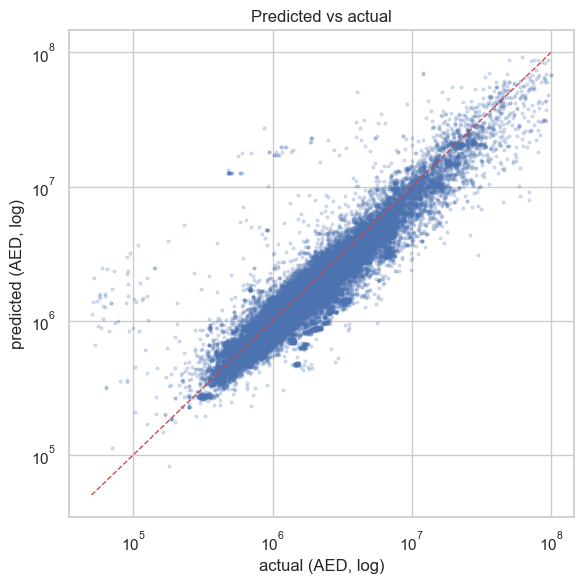

In [6]:
s = ev.sample(min(50_000, len(ev)), random_state=CFG["seed"])
lo, hi = ev["y_true"].min(), ev["y_true"].max()
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(s["y_true"], s["y_pred"], s=4, alpha=0.2)
ax.plot([lo, hi], [lo, hi], "r--", lw=1)
ax.set(xscale="log", yscale="log", xlabel="actual (AED, log)",
       ylabel="predicted (AED, log)", title="Predicted vs actual")
save(fig, "pred_vs_actual")

## 3. Error distribution and bias

pct_err > 0 means over prediction. A median near zero means unbiased overall. The
spread is the typical error. The right panel checks whether error grows with
price

median signed % error (bias): -8.6%
median absolute % error:      13.7%
saved C:\Users\Maga\Study\CSCi323\Project\reports\figures\residuals.png


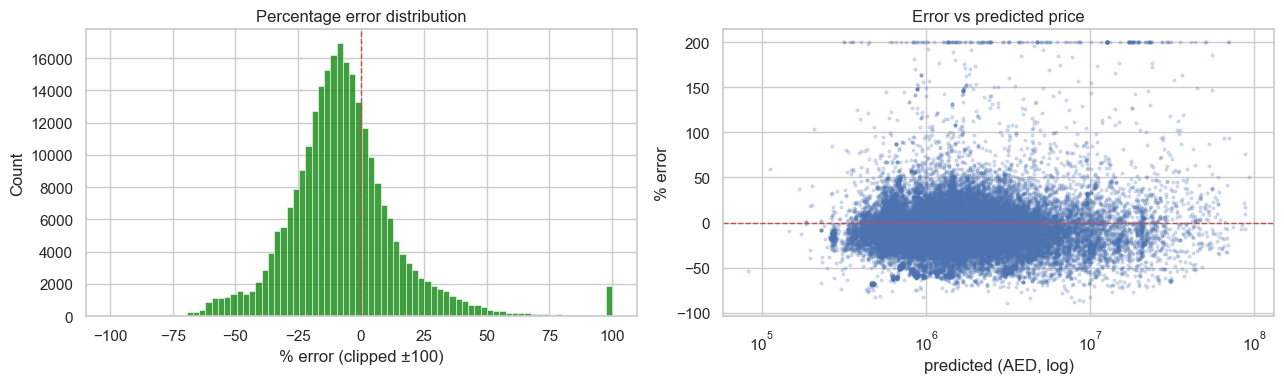

In [ ]:
print(f"median signed % error (bias): {ev['pct_err'].median():.1f}%")
print(f"median absolute % error: {ev['abs_pct_err'].median():.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(ev["pct_err"].clip(-100, 100), bins=80, ax=axes[0], color="green")
axes[0].axvline(0, color="r", ls="--", lw=1)
axes[0].set(title="Percentage error distribution", xlabel="% error (clipped ±100)")

s2 = ev.sample(min(50_000, len(ev)), random_state=CFG["seed"])
axes[1].scatter(s2["y_pred"], s2["pct_err"].clip(-200, 200), s=4, alpha=0.2)
axes[1].axhline(0, color="r", ls="--", lw=1)
axes[1].set(xscale="log", xlabel="predicted (AED, log)", ylabel="% error",
            title="Error vs predicted price")
save(fig, "residuals")

## 4. Error by segment

Where the model struggles. Median absolute % error by property type, registration
type, price band, and the worst communities.


median abs % error by property_type_en:
                       n  median_abs_pct
property_type_en                        
Building             671           35.21
Land               22795           14.95
Unit              216946           13.60
Villa              21823           12.76

median abs % error by reg_type_en:
                          n  median_abs_pct
reg_type_en                                
Existing Properties   92510           14.45
Off-Plan Properties  169725           13.26

median abs % error by price band:
price_band
(49999.0, 850000.0]        11.72
(850000.0, 1277803.0]      12.04
(1277803.0, 2000000.0]     13.73
(2000000.0, 3321132.0]     13.25
(3321132.0, 100000000.0]   19.23
Name: abs_pct_err, dtype: float64
saved C:\Users\Maga\Study\CSCi323\Project\reports\figures\error_by_price_band.png

worst-12 communities by median abs % error (n>=100):
                                 n  median_abs_pct
area_name_en                                      
Al Safouh First   

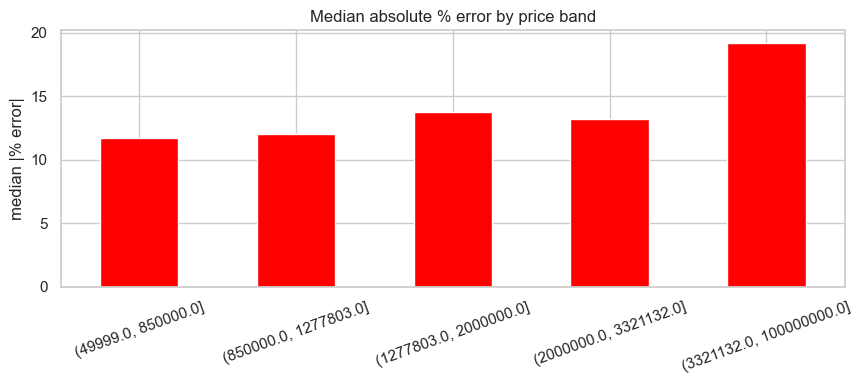

In [10]:
def seg(col, min_n=50):
    g = (ev.groupby(col)
           .agg(n=("y_true", "size"), median_abs_pct=("abs_pct_err", "median")))
    return g[g["n"] >= min_n].sort_values("median_abs_pct", ascending=False)

for col in ["property_type_en", "reg_type_en"]:
    print(f"\nmedian abs % error by {col}:")
    print(seg(col))

ev["price_band"] = pd.qcut(ev["y_true"], 5, precision=0)
band = ev.groupby("price_band", observed=True)["abs_pct_err"].median()
print("\nmedian abs % error by price band:")
print(band)

fig, ax = plt.subplots(figsize=(9, 4))
band.plot(kind="bar", ax=ax, color="red")
ax.set(title="Median absolute % error by price band", ylabel="median |% error|", xlabel="")
ax.tick_params(axis="x", labelrotation=20)
save(fig, "error_by_price_band")

print("\nworst-12 communities by median abs % error (n>=100):")
print(seg("area_name_en", min_n=100).head(12))

## 5. Feature importance

Which features the model actually relies on, computed on R2 and only 30k samples for speed

saved C:\Users\Maga\Study\CSCi323\Project\reports\figures\feature_importance.png


procedure_area         1.39
area_name_en           0.23
property_usage_en      0.08
procedure_name_en      0.07
bedrooms               0.06
rooms_en               0.06
nearest_mall_en        0.06
nearest_landmark_en    0.05
has_parking            0.04
nearest_metro_en       0.04
reg_type_en            0.01
property_type_en       0.01
property_sub_type_en   0.01
sale_month             0.01
sale_year              0.00
dtype: float64

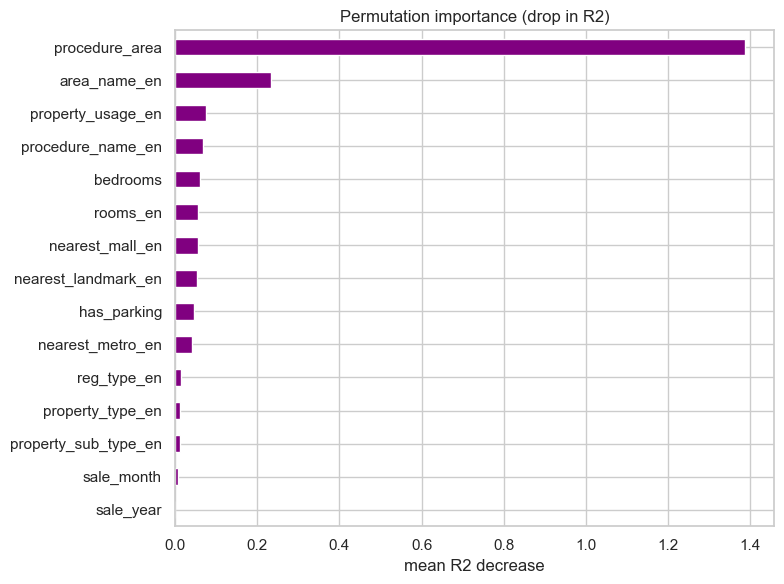

In [15]:
samp = ev.sample(min(30_000, len(ev)), random_state=CFG["seed"]).index
pi = permutation_importance(model, X_test.loc[samp], y_test.loc[samp],
                            scoring="r2", n_repeats=5,
                            random_state=CFG["seed"], n_jobs=1)
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
imp.plot(kind="barh", ax=ax, color="purple")
ax.set(title="Permutation importance (drop in R2)", xlabel="mean R2 decrease")
save(fig, "feature_importance")
imp.sort_values(ascending=False)

## 6. Worst predictions

The 20 largest percentage errors: unusual or ultra luxury properties

In [14]:
cols = ["property_type_en", "area_name_en", "rooms_en", "procedure_area",
        "y_true", "y_pred", "pct_err"]
ev.sort_values("abs_pct_err", ascending=False).head(20)[cols]

,property_type_en,area_name_en,rooms_en,procedure_area,y_true,y_pred,pct_err
180236,Building,Wadi Al Safa 7,Unknown,"28,435.97","175,154.00","41,094,770.13","23,362.08"
190539,Unit,Burj Khalifa,3 B/R,169.18,"55,355.00","4,228,504.03","7,538.88"
72384,Unit,Al Khairan First,3 B/R,159.73,"57,942.00","3,310,432.66","5,613.36"
180378,Building,Wadi Al Safa 7,Unknown,"4,403.82","637,471.00","34,213,366.73","5,267.05"
194915,Villa,Al Hebiah Fourth,4 B/R,201.93,"69,396.00","3,524,824.28","4,979.29"
75394,Unit,Marsa Dubai,3 B/R,164.76,"55,154.00","2,786,495.98","4,952.21"
190303,Unit,Burj Khalifa,2 B/R,108.83,"65,244.00","3,291,473.75","4,944.87"
186728,Building,Al Barsha South Fourth,Unknown,"2,242.51","849,999.00","39,205,837.70","4,512.46"
190728,Unit,Burj Khalifa,1 B/R,68.56,"59,122.00","2,468,376.69","4,075.06"
79963,Unit,Burj Khalifa,2 B/R,124.58,"60,064.00","2,496,774.16","4,056.86"
